# EDA exploratória da base "silver" — escola pública, no censo, com alvo do IDEB

Contexto: no `06_eda_ideb_escola.ipynb` confirmei que dá pra montar uma variável-alvo a partir do `br_inep_ideb/escola`, que o `id_escola` bate de verdade com a `escola_completo`, e tomei quatro decisões: (1) alvo binário `ideb >= 6.0`, (2) só rede pública, (3) só escolas que aparecem na `escola_completo`, e (4) ano de alinhamento = **2025** (decisão final, documentada na Seção 15 do notebook 06: é o ciclo do IDEB com maior preenchimento entre os mais recentes, é posterior ao Censo de 2024 — lógica causal mais defensável —, e faz sentido porque infraestrutura escolar muda pouco de um ano pro outro, então o Censo de 2024 ainda descreve bem a escola em 2025).

**Objetivo deste notebook:** agora que tenho a base já filtrada (a "silver"), fazer uma EDA de verdade em cima das 455 colunas da `escola_completo` como *features* candidatas — separando por grupo temático (infraestrutura, corpo docente, matrícula, etc., já que 455 colunas de uma vez não dá pra olhar direito), vendo preenchimento por grupo, e calculando correlação de cada variável numérica com os dois candidatos a alvo (`ideb` e `taxa_aprovacao`, já que ainda não fechei qual dos dois vai virar a variável-resposta final — ver pendência no `06_eda_ideb_escola.ipynb`).

Não decido nenhuma feature final aqui — isso é levantamento; a seleção de fato acontece quando eu formalizar o pré-processamento em `src/preprocessing`.

In [14]:
import sys
sys.path.append("../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 100)

## 1. Montar a base "silver" (escola pública, no censo, com alvo do IDEB)

**Atualização:** esta célula deixou de reconstruir os quatro filtros aqui dentro do notebook. Agora chamo `ler_base_escola_modelo()` (`src/preprocessing/build_base_escola.py`), que já aplica os mesmos quatro filtros decididos no `06_eda_ideb_escola.ipynb` (crosswalk com `escola_completo`, rede pública, anos iniciais, ano) e também já traduz as colunas categóricas usando o dicionário oficial do INEP (Achado 26 em `reports/decisoes.md`) — a junção com o dicionário deixou de ser um passo deste notebook e virou parte do pré-processamento, publicada como uma camada nova no S3 (`silver_modelo`). Isso significa que, a partir desta execução, colunas como `tipo_localizacao`/`tipo_regulamentacao`/`tipo_situacao_funcionamento` (Seção 7 abaixo) aparecem já traduzidas pra texto, não mais como código numérico cru.


In [15]:
from src.preprocessing.build_base_escola import ler_base_escola_modelo, ANO_ESCOLHIDO

base_eda = ler_base_escola_modelo()

print(f"ANO_ESCOLHIDO = {ANO_ESCOLHIDO} (decisão final - ver Seção 15 do notebook 06)")
print(f"\nbase_eda final: {base_eda.shape[0]:,} escolas, {base_eda.shape[1]} colunas")
print(f"% com 'ideb' preenchido: {base_eda['ideb'].notna().mean() * 100:.2f}%")
print(f"% com 'taxa_aprovacao' preenchido: {base_eda['taxa_aprovacao'].notna().mean() * 100:.2f}%")
base_eda.head()


Lendo base_escola_modelo do cache local: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\data\processed\base_escola_modelo.parquet
ANO_ESCOLHIDO = 2025 (decisão final - ver Seção 15 do notebook 06)

base_eda final: 63,537 escolas, 348 colunas
% com 'ideb' preenchido: 66.53%
% com 'taxa_aprovacao' preenchido: 68.00%


,id_escola,id_municipio,sigla_uf,rede,taxa_aprovacao,ideb,sigla_uf_censo,id_municipio_censo,rede_censo,tipo_localizacao,tipo_localizacao_diferenciada,tipo_situacao_funcionamento,id_orgao_regional,vinculo_secretaria_educacao,vinculo_seguranca_publica,vinculo_secretaria_saude,vinculo_outro_orgao,poder_publico_parceria,tipo_regulamentacao,tipo_responsavel_regulamentacao,local_funcionamento_predio_escolar,tipo_local_funcionamento_predio_escolar,local_funcionamento_socioeducativo,local_funcionamento_unidade_prisional,local_funcionamento_prisional_socio,local_funcionamento_galpao,local_funcionamento_outra_escola,local_funcionamento_outros,predio_compartilhado,agua_potavel,agua_rede_publica,agua_poco_artesiano,agua_cacimba,agua_fonte_rio,agua_inexistente,energia_rede_publica,energia_gerador_fossil,energia_renovavel,energia_inexistente,esgoto_rede_publica,esgoto_fossa,esgoto_fossa_septica,esgoto_fossa_comum,esgoto_inexistente,lixo_servico_coleta,lixo_queima,lixo_enterrado,lixo_destino_final_publico,lixo_descarta_outra_area,tratamento_lixo_separacao,...,quantidade_matricula_zona_residencia_urbana,quantidade_matricula_zona_residencia_rural,quantidade_matricula_zona_residencia_nao_aplicavel,quantidade_matricula_utiliza_transporte_publico,quantidade_matricula_transporte_estadual,quantidade_matricula_transporte_municipal,quantidade_docente_educacao_basica,quantidade_docente_infantil,quantidade_docente_infantil_creche,quantidade_docente_infantil_pre_escola,quantidade_docente_fundamental,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_docente_profissional,quantidade_docente_profissional_tecnica,quantidade_docente_eja,quantidade_docente_eja_fundamental,quantidade_docente_eja_medio,quantidade_docente_especial,quantidade_docente_especial_comum,quantidade_docente_especial_exclusiva,quantidade_turma_educacao_basica,quantidade_turma_infantil,quantidade_turma_infantil_integral,quantidade_turma_infantil_creche,quantidade_turma_infantil_creche_integral,quantidade_turma_infantil_pre_escola,quantidade_turma_infantil_pre_escola_integral,quantidade_turma_fundamental,quantidade_turma_fundamental_integral,quantidade_turma_fundamental_anos_iniciais,quantidade_turma_fundamental_anos_iniciais_integral,quantidade_turma_fundamental_anos_finais,quantidade_turma_fundamental_anos_finais_integral,quantidade_turma_medio,quantidade_turma_medio_integral,quantidade_turma_profissional,quantidade_turma_profissional_tecnica,quantidade_turma_eja,quantidade_turma_eja_fundamental,quantidade_turma_eja_medio,quantidade_turma_especial,quantidade_turma_especial_comum,quantidade_turma_especial_exclusiva,quantidade_turma_diurno,quantidade_turma_noturno,quantidade_turma_ead,ano,alvo_ideb
0,11000597,1100205,RO,estadual,NaN,NaN,RO,1100205,2,Urbana,codigo_nao_documentado_0,Em atividade,9.0,1,0,0,0,0,Sim,Estadual,1,Próprio,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,...,431,17,0,1,0,1,26,0,0,0,26,0,26,13,0,0,0,0,0,26,26,0,16,0,0,0,0,0,0,14,14,0,0,14,14,2,2,0,0,0,0,0,10,10,0,16,0,0,2024,<NA>
1,11000970,1100205,RO,estadual,NaN,NaN,RO,1100205,2,Urbana,codigo_nao_documentado_0,Em atividade,9.0,1,0,0,0,0,Sim,Estadual,1,Próprio,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,...,515,98,0,97,0,97,26,0,0,0,26,0,26,0,0,0,0,0,0,26,26,0,27,0,0,0,0,0,0,27,0,0,0,27,0,0,0,0,0,0,0,0,18,18,0,27,0,0,2024,<NA>
2,11001240,1100205,RO,estadual,NaN,NaN,RO,1100205,2,Urbana,codigo_nao_documentado_0,Em atividade,9.0,1,0,0,0,0,Sim,Estadual,1,Próprio,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,1,...,754,44,0,0,0,0,18,0,0,0,18,0,18,0,0,0,0,0,0,18,18,0,28,0,0,0,0,0,0,28,0,0,0,28,0,0,0,0,0,0,0,0,24,24,0,28,0,0,2024,<NA>
3,11004894,1100809,RO,estadual,NaN,NaN,RO,1100809,2,Urbana,codigo_nao_documentado_0,Em atividade,9.0,1,0,0,0,0,Sim,Estadual,1,Próprio,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,...,530,163,0,163,158,5,22,0,0,0,21,0,21,0,0,0,10,10,0,22,22,0,27,0,0,0,0,0,0,22,0,0,0,22,0,0,0,0,0,5,5,0,

## 2. Classificação temática das 455 colunas

455 colunas de uma vez não dá pra olhar com cuidado, então separo por grupo temático usando palavras-chave no nome da coluna (o mesmo tipo de abordagem que já usei pra achar candidatas a variável-alvo no `04_eda_escola_completo.ipynb`). Colunas que não batem com nenhum grupo ficam numa categoria "não classificada" pra eu revisar manualmente depois.

In [16]:
GRUPOS_TEMATICOS = {
    "infraestrutura": [
        "agua", "energia", "esgoto", "internet", "banda_larga", "biblioteca", "laboratorio",
        "quadra", "sala_", "dependencia", "acessibilidade", "cozinha", "refeitorio", "auditorio",
        "parque_infantil", "patio", "almoxarifado", "sanitario", "lixo", "energia_inexistente",
        "dependencia_lixo", "recurso", "equipamento", "banheiro", "piscina", "area_verde",
        "secretaria", "despensa", "terreirao", "viveiro", "predio_compartilhado",
        "local_funcionamento", "tipo_rede_local", "material_pedagogico",
    ],
    "corpo_docente": ["docente", "professor"],
    "corpo_tecnico_administrativo": [
        "profissional_administrativo", "profissional_servico_geral", "profissional_bibliotecario",
        "profissional_saude", "profissional_coordenador", "profissional_psicologo",
        "profissional_nutricionista", "profissional_pedagogia", "profissional_secretario",
        "profissional_seguranca", "profissional_monitor", "profissional_assistente_social",
        "profissional_tradutor", "profissional_fonaudiologo", "profissional_alimentacao",
        "quantidade_profissional",
    ],
    "quantidade_matricula": ["matricula", "aluno", "estudante"],
    "localizacao": ["zona", "localizacao", "localidade", "endereco", "distrito", "regiao"],
    "identificacao": ["id_", "co_", "nome", "entidade", "cnpj", "cep", "sigla_uf", "ano"],
    "gestao_administrativa": ["dependencia_administrativa", "convenio", "vinculo", "regulamentacao",
                              "categoria", "conveniada", "orgao"],
    "modalidade_etapa": ["etapa", "modalidade", "ensino_", "educacao_", "curso", "eja", "creche",
                          "pre_escola", "fundamental", "medio", "profissionalizante"],
    "programa": ["programa"],
}

colunas_ja_usadas = {"id_escola", "id_municipio", "sigla_uf", "rede", "taxa_aprovacao", "ideb"}
colunas_a_classificar = [c for c in base_eda.columns if c not in colunas_ja_usadas]

classificacao = {}
for coluna in colunas_a_classificar:
    coluna_lower = coluna.lower()
    grupo_encontrado = None
    for grupo, palavras in GRUPOS_TEMATICOS.items():
        if any(p in coluna_lower for p in palavras):
            grupo_encontrado = grupo
            break
    classificacao[coluna] = grupo_encontrado or "nao_classificada"

resumo_classificacao = pd.Series(classificacao).value_counts()
print("Colunas por grupo temático:")
print(resumo_classificacao)

print("\nColunas 'nao_classificada' (revisar manualmente, uma a uma):")
nao_classificadas = [c for c, g in classificacao.items() if g == "nao_classificada"]
for c in nao_classificadas:
    print(" -", c)
print(f"... total: {len(nao_classificadas)} colunas não classificadas")

Colunas por grupo temático:
infraestrutura                  130
quantidade_matricula             88
corpo_tecnico_administrativo     29
nao_classificada                 28
modalidade_etapa                 26
corpo_docente                    17
identificacao                    12
gestao_administrativa            10
localizacao                       2
Name: count, dtype: int64

Colunas 'nao_classificada' (revisar manualmente, uma a uma):
 - rede_censo
 - tipo_situacao_funcionamento
 - profissional_gestao
 - alimentacao
 - exame_selecao
 - redes_sociais
 - tipo_proposta_pedagogica
 - tipo_aee
 - tipo_atividade_complementar
 - escolarizacao
 - mediacao_presencial
 - mediacao_semipresencial
 - mediacao_ead
 - regular
 - diurno
 - noturno
 - ead
 - quantidade_turma_infantil
 - quantidade_turma_infantil_integral
 - quantidade_turma_profissional
 - quantidade_turma_profissional_tecnica
 - quantidade_turma_especial
 - quantidade_turma_especial_comum
 - quantidade_turma_especial_exclusiva
 - qua

## 3. Preenchimento por grupo temático

Antes de olhar correlação, preciso saber o quanto cada grupo está preenchido nesta base já filtrada (455 colunas, mas agora só nas ~escolas do recorte) — um grupo interessante mas com preenchimento muito ruim não serve pra muita coisa.

In [17]:
linhas_resumo = []
for coluna, grupo in classificacao.items():
    linhas_resumo.append({
        "grupo": grupo,
        "coluna": coluna,
        "dtype": str(base_eda[coluna].dtype),
        "pct_preenchido": round(base_eda[coluna].notna().mean() * 100, 2),
    })

resumo_preenchimento = pd.DataFrame(linhas_resumo).sort_values(["grupo", "pct_preenchido"], ascending=[True, False])

print("Preenchimento médio por grupo:")
print(resumo_preenchimento.groupby("grupo")["pct_preenchido"].agg(["mean", "min", "max", "count"]).round(2))

print("\nDetalhe completo (coluna a coluna):")
print(resumo_preenchimento.to_string(index=False))

Preenchimento médio por grupo:
                                mean     min    max  count
grupo                                                     
corpo_docente                  96.56   96.56   96.6     17
corpo_tecnico_administrativo   96.60   96.60   96.6     29
gestao_administrativa          97.27   96.53  100.0     10
identificacao                  97.48   96.57  100.0     12
infraestrutura                 96.63   93.76  100.0    130
localizacao                   100.00  100.00  100.0      2
modalidade_etapa               96.57   96.57   96.6     26
nao_classificada               96.12   66.53  100.0     28
quantidade_matricula           96.57   96.57   96.6     88

Detalhe completo (coluna a coluna):
                       grupo                                                  coluna dtype  pct_preenchido
               corpo_docente                                    dormitorio_professor Int64           96.60
               corpo_docente                      quantidade_docente_

## 4. Distribuição do alvo nesta base: `ideb` e `taxa_aprovacao`

Antes de correlacionar qualquer coisa, olho a distribuição dos dois candidatos a variável-alvo já dentro deste recorte específico (censo + pública + anos iniciais + ano escolhido) — pra confirmar que continuam com cara de dado real, e não um artefato do filtro.

Distribuição de 'ideb' na base_eda:
count    42273.000000
mean         6.055092
std          1.031166
min          1.400000
25%          5.400000
50%          6.100000
75%          6.700000
max         10.000000
Name: ideb, dtype: float64

Distribuição de 'taxa_aprovacao' na base_eda:
count    43204.000000
mean        97.923921
std          3.558921
min         58.100000
25%         97.300000
50%         99.500000
75%        100.000000
max        100.000000
Name: taxa_aprovacao, dtype: float64


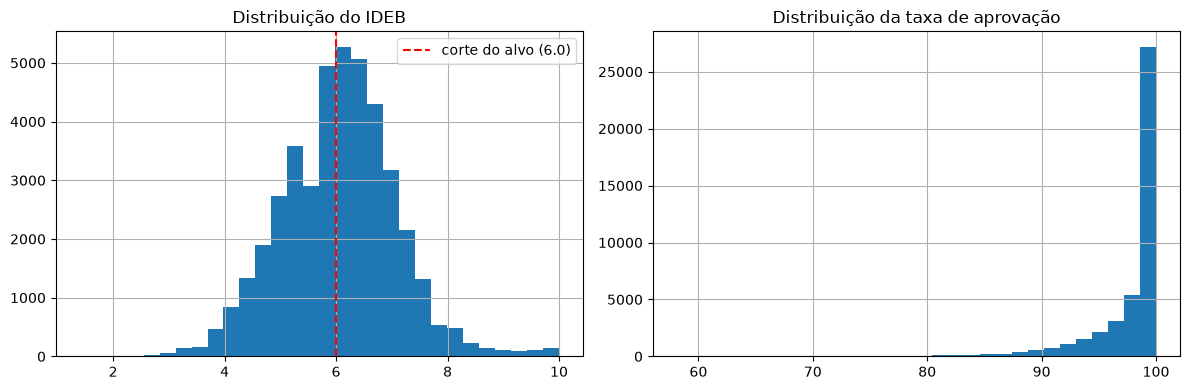

In [18]:
print("Distribuição de 'ideb' na base_eda:")
print(base_eda["ideb"].describe())

print("\nDistribuição de 'taxa_aprovacao' na base_eda:")
print(base_eda["taxa_aprovacao"].describe())

fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
base_eda["ideb"].dropna().hist(bins=30, ax=eixos[0])
eixos[0].set_title("Distribuição do IDEB")
eixos[0].axvline(6.0, color="red", linestyle="--", label="corte do alvo (6.0)")
eixos[0].legend()

base_eda["taxa_aprovacao"].dropna().hist(bins=30, ax=eixos[1])
eixos[1].set_title("Distribuição da taxa de aprovação")
plt.tight_layout()
plt.show()

## 5. Correlação de cada variável numérica com `ideb` e `taxa_aprovacao`

Uso correlação de Spearman (baseada em ranking, não assume relação linear nem distribuição normal) — mais robusta pra essas colunas de contagem/proporção, que costumam ser bem enviesadas. Calculo contra os dois candidatos a alvo, já que ainda não decidi qual vai ser o definitivo (pendência registrada no `06_eda_ideb_escola.ipynb`).

In [19]:
colunas_numericas = [
    c for c in base_eda.columns
    if c not in colunas_ja_usadas and pd.api.types.is_numeric_dtype(base_eda[c])
]

linhas_correlacao = []
for coluna in colunas_numericas:
    serie = base_eda[coluna]
    if serie.notna().sum() < 30:
        continue  # preenchimento baixo demais pra uma correlação minimamente confiável
    corr_ideb = base_eda[[coluna, "ideb"]].dropna().corr(method="spearman").iloc[0, 1]
    corr_taxa = base_eda[[coluna, "taxa_aprovacao"]].dropna().corr(method="spearman").iloc[0, 1]
    linhas_correlacao.append({
        "grupo": classificacao.get(coluna, "nao_classificada"),
        "coluna": coluna,
        "pct_preenchido": round(serie.notna().mean() * 100, 2),
        "corr_ideb": round(corr_ideb, 3) if pd.notna(corr_ideb) else np.nan,
        "corr_taxa_aprovacao": round(corr_taxa, 3) if pd.notna(corr_taxa) else np.nan,
    })

tabela_correlacao = pd.DataFrame(linhas_correlacao)
tabela_correlacao["abs_corr_ideb"] = tabela_correlacao["corr_ideb"].abs()

print(f"Total de colunas numéricas avaliadas: {len(tabela_correlacao)}")
print("\n=== Top 30 por correlação absoluta com 'ideb' ===")
print(tabela_correlacao.sort_values("abs_corr_ideb", ascending=False).head(30).to_string(index=False))

Total de colunas numéricas avaliadas: 328

=== Top 30 por correlação absoluta com 'ideb' ===
                grupo                                       coluna  pct_preenchido  corr_ideb  corr_taxa_aprovacao  abs_corr_ideb
     nao_classificada                                    alvo_ideb           66.53      0.863                0.352          0.863
 quantidade_matricula                  quantidade_matricula_branca           96.57      0.403               -0.016          0.403
       infraestrutura                    quantidade_equipamento_tv           96.60      0.276                0.054          0.276
       infraestrutura                   acesso_internet_computador           96.60      0.264                0.063          0.264
gestao_administrativa                orgao_associacao_pais_mestres           96.60      0.253               -0.018          0.253
       infraestrutura                  tratamento_lixo_inexistente           96.60     -0.247               -0.033          0.2

In [20]:
print("=== Top 5 de cada grupo temático, por correlação absoluta com 'ideb' ===")
for grupo, sub in tabela_correlacao.groupby("grupo"):
    print(f"\n--- {grupo} ---")
    print(sub.sort_values("abs_corr_ideb", ascending=False).head(5).to_string(index=False))

=== Top 5 de cada grupo temático, por correlação absoluta com 'ideb' ===

--- corpo_docente ---
        grupo                                       coluna  pct_preenchido  corr_ideb  corr_taxa_aprovacao  abs_corr_ideb
corpo_docente quantidade_docente_fundamental_anos_iniciais           96.56      0.231               -0.039          0.231
corpo_docente           quantidade_docente_eja_fundamental           96.56     -0.170               -0.055          0.170
corpo_docente                       quantidade_docente_eja           96.56     -0.161               -0.049          0.161
corpo_docente   quantidade_docente_fundamental_anos_finais           96.56     -0.130               -0.102          0.130
corpo_docente               quantidade_docente_fundamental           96.56      0.121               -0.090          0.121

--- corpo_tecnico_administrativo ---
                       grupo                            coluna  pct_preenchido  corr_ideb  corr_taxa_aprovacao  abs_corr_ideb
corpo_te

## 6. Visualizando as variáveis mais correlacionadas

Um gráfico de barras com as top 15 (por correlação absoluta com `ideb`), pra ver rapidamente quais grupos temáticos dominam o topo — e um scatter/boxplot das 3 mais correlacionadas, pra confirmar visualmente que a correlação numérica não é um artefato (ex.: outliers puxando o número).

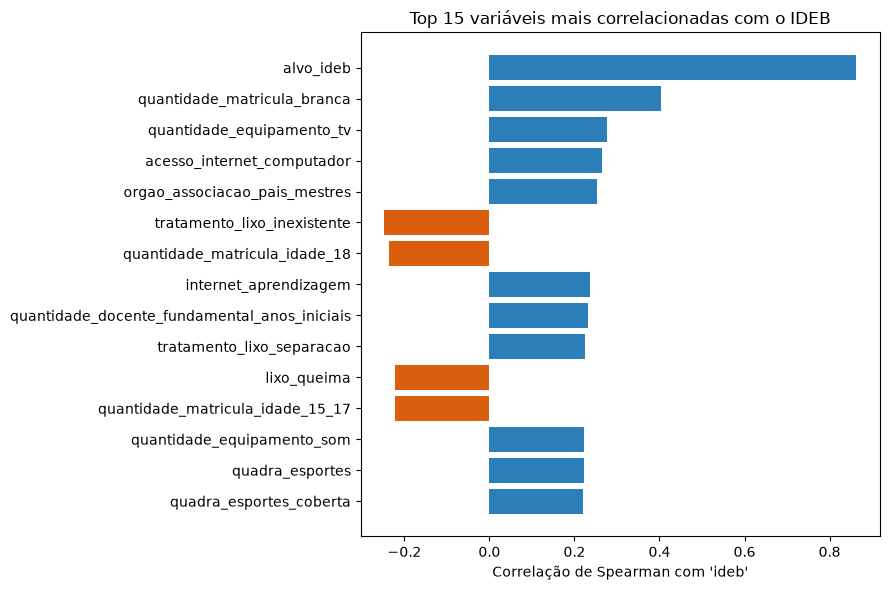

In [21]:
top_15 = tabela_correlacao.sort_values("abs_corr_ideb", ascending=False).head(15)

plt.figure(figsize=(9, 6))
cores = ["#2c7fb8" if v >= 0 else "#d95f0e" for v in top_15["corr_ideb"]]
plt.barh(top_15["coluna"], top_15["corr_ideb"], color=cores)
plt.xlabel("Correlação de Spearman com 'ideb'")
plt.title("Top 15 variáveis mais correlacionadas com o IDEB")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

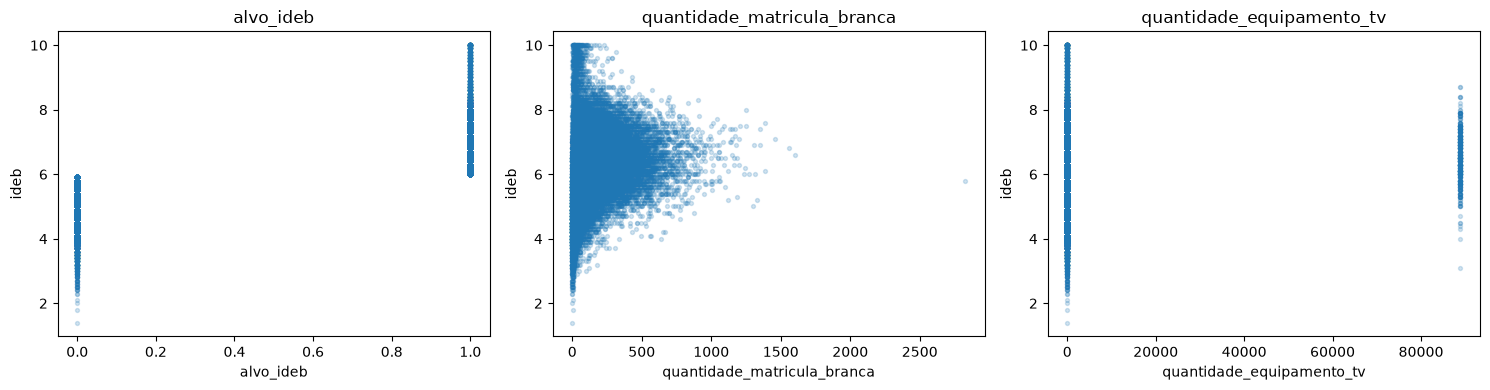

In [22]:
top_3_colunas = top_15["coluna"].head(3).tolist()

fig, eixos = plt.subplots(1, len(top_3_colunas), figsize=(5 * len(top_3_colunas), 4))
if len(top_3_colunas) == 1:
    eixos = [eixos]

for eixo, coluna in zip(eixos, top_3_colunas):
    dados = base_eda[[coluna, "ideb"]].dropna()
    eixo.scatter(dados[coluna], dados["ideb"], alpha=0.2, s=8)
    eixo.set_xlabel(coluna)
    eixo.set_ylabel("ideb")
    eixo.set_title(coluna)

plt.tight_layout()
plt.show()

## 6.1 Comparando lado a lado: top 10 correlacionadas com `ideb` vs. top 10 com `taxa_aprovacao`

Como ainda não decidi qual dos dois vai ser o alvo final, quero ver se as variáveis mais fortes são as mesmas nos dois casos, ou se cada métrica "escuta" um sinal diferente da escola — isso também ajuda na decisão de qual usar.

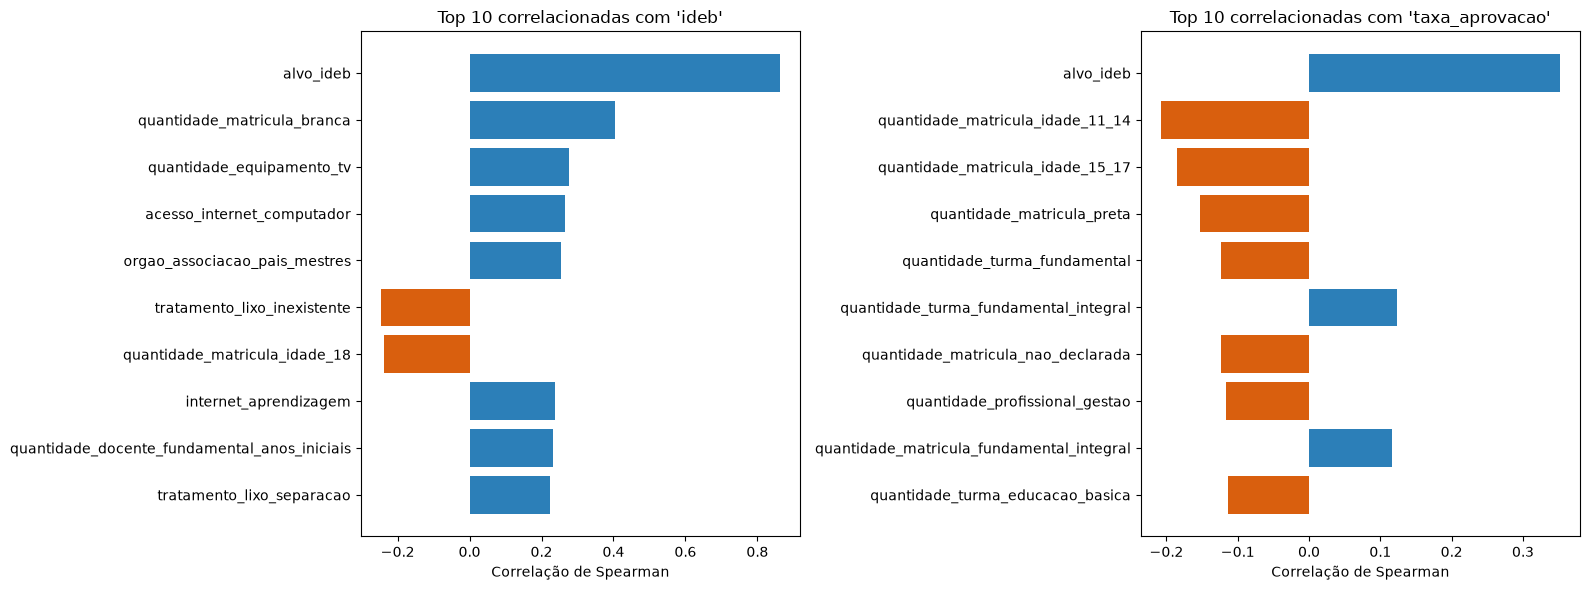

Colunas que aparecem no top 10 dos dois: 1
 - alvo_ideb


In [23]:
tabela_correlacao["abs_corr_taxa"] = tabela_correlacao["corr_taxa_aprovacao"].abs()

top_10_ideb = tabela_correlacao.sort_values("abs_corr_ideb", ascending=False).head(10)
top_10_taxa = tabela_correlacao.sort_values("abs_corr_taxa", ascending=False).head(10)

fig, (eixo_ideb, eixo_taxa) = plt.subplots(1, 2, figsize=(16, 6))

cores_ideb = ["#2c7fb8" if v >= 0 else "#d95f0e" for v in top_10_ideb["corr_ideb"]]
eixo_ideb.barh(top_10_ideb["coluna"], top_10_ideb["corr_ideb"], color=cores_ideb)
eixo_ideb.set_title("Top 10 correlacionadas com 'ideb'")
eixo_ideb.set_xlabel("Correlação de Spearman")
eixo_ideb.invert_yaxis()

cores_taxa = ["#2c7fb8" if v >= 0 else "#d95f0e" for v in top_10_taxa["corr_taxa_aprovacao"]]
eixo_taxa.barh(top_10_taxa["coluna"], top_10_taxa["corr_taxa_aprovacao"], color=cores_taxa)
eixo_taxa.set_title("Top 10 correlacionadas com 'taxa_aprovacao'")
eixo_taxa.set_xlabel("Correlação de Spearman")
eixo_taxa.invert_yaxis()

plt.tight_layout()
plt.show()

colunas_em_comum = set(top_10_ideb["coluna"]) & set(top_10_taxa["coluna"])
print(f"Colunas que aparecem no top 10 dos dois: {len(colunas_em_comum)}")
for c in colunas_em_comum:
    print(" -", c)

**Achado que merece atenção especial:** `quantidade_matricula_branca` (contagem de matrículas de alunos que se autodeclaram brancos) apareceu como a variável de maior correlação absoluta com `ideb` (0,403) de toda a base — mais forte que qualquer variável de infraestrutura. Isso não é uma relação causal (a cor da pele do aluno não "causa" desempenho), e sim reflexo de um problema bem documentado no Brasil: composição racial da escola correlaciona com contexto socioeconômico e histórico de desigualdade regional/urbana, que por sua vez afeta desempenho. Uso essa variável aqui só pra descrever o padrão (é isso que a EDA é pra fazer). Incluir ou não como feature direta do modelo é uma decisão sensível: usá-la sem tratamento pode fazer o modelo aprender um proxy racial em vez de um fator realmente acionável por política pública (como infraestrutura ou corpo docente). Registro esse ponto aqui como um cuidado ético explícito do projeto, a ser resolvido quando eu fechar a lista final de features em `src/preprocessing` — não é uma decisão que tomo dentro da EDA.

## 7. Variáveis categóricas — distribuição e associação com o alvo

Até aqui só olhei variáveis numéricas (contagens, correlação). Mas a `escola_completo` tem bastante coluna categórica/código (`sigla_uf`, `tipo_localizacao`, `tipo_situacao_funcionamento`, `tipo_regulamentacao`, etc.) que a correlação de Spearman não captura bem quando são poucas categorias sem ordem natural. Identifico aqui as colunas de baixa cardinalidade (poucos valores distintos — jeito prático de achar "categóricas" mesmo em colunas que vieram como número/código) e, pra cada uma, olho a distribuição de escolas por categoria e a taxa de escolas "boas" (uso o corte já decidido, `ideb >= 6.0`, só para esta EDA — não é a implementação final do alvo).

**Atualização:** o dicionário oficial de código→texto do `br_inep_censo_escolar` (mencionado como próximo passo na primeira versão desta nota) foi ingerido, testado contra os códigos reais e integrado ao pré-processamento (Achado 26 em `reports/decisoes.md`) — a tradução já vem pronta na `base_eda` carregada na Seção 1, então os códigos numéricos (ex.: `tipo_localizacao` 1/2) já aparecem aqui como texto (ex.: "Urbana"/"Rural").


In [24]:
base_eda["alvo_binario_ideb"] = (base_eda["ideb"] >= 6.0).astype("Int64")
base_eda.loc[base_eda["ideb"].isna(), "alvo_binario_ideb"] = pd.NA

colunas_candidatas_categoricas = [
    c for c in base_eda.columns
    if c not in colunas_ja_usadas | {"alvo_binario_ideb"}
    and base_eda[c].nunique(dropna=True) <= 15
    and base_eda[c].nunique(dropna=True) >= 2
]

print(f"Colunas de baixa cardinalidade encontradas (candidatas a categóricas): {len(colunas_candidatas_categoricas)}")

# Foco nas mais interessantes pra essa EDA (as outras são flags binárias de infraestrutura,
# já cobertas na correlação da Seção 5) - variáveis de identificação/localização/organização.
colunas_categoricas_foco = [
    c for c in ["rede", "sigla_uf", "tipo_localizacao", "tipo_localizacao_diferenciada",
                "tipo_situacao_funcionamento", "tipo_regulamentacao",
                "tipo_responsavel_regulamentacao"]
    if c in base_eda.columns
]

for coluna in colunas_categoricas_foco:
    print(f"\n=== {coluna} ===")
    resumo = base_eda.groupby(coluna, dropna=False).agg(
        escolas=("id_escola", "size"),
        pct_ideb_preenchido=("ideb", lambda s: round(s.notna().mean() * 100, 2)),
        ideb_medio=("ideb", "mean"),
        pct_acima_da_meta=("alvo_binario_ideb", lambda s: round(s.mean(skipna=True) * 100, 2) if s.notna().any() else np.nan),
    ).round(2).sort_values("escolas", ascending=False)
    print(resumo.to_string())

Colunas de baixa cardinalidade encontradas (candidatas a categóricas): 194

=== rede ===
           escolas  pct_ideb_preenchido  ideb_medio  pct_acima_da_meta
rede                                                                  
municipal    50151                72.90        6.01              52.63
estadual     13361                42.61        6.31              68.28
federal         25                88.00        6.98              90.91

=== sigla_uf ===
          escolas  pct_ideb_preenchido  ideb_medio  pct_acima_da_meta
sigla_uf                                                             
SP           7350                80.52        6.51               80.2
BA           6072                57.49        5.26              19.85
MG           5953                67.31        6.33              70.23
RS           4120                77.99        6.24              63.52
MA           3976                52.69        5.27              19.67
PA           3786                64.24        5.

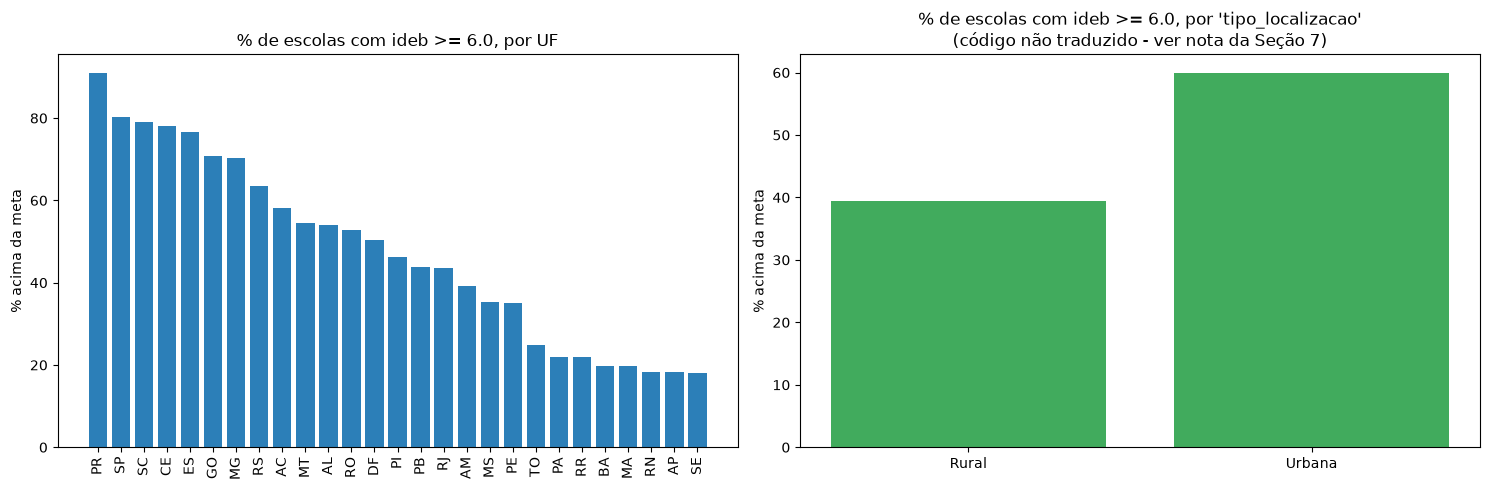

In [25]:
fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

resumo_uf = (
    base_eda.groupby("sigla_uf")["alvo_binario_ideb"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)
eixos[0].bar(resumo_uf.index, resumo_uf.values, color="#2c7fb8")
eixos[0].set_title("% de escolas com ideb >= 6.0, por UF")
eixos[0].set_ylabel("% acima da meta")
eixos[0].tick_params(axis="x", rotation=90)

if "tipo_localizacao" in base_eda.columns:
    resumo_localizacao = (
        base_eda.groupby("tipo_localizacao")["alvo_binario_ideb"]
        .mean()
        .mul(100)
        .round(2)
    )
    eixos[1].bar(resumo_localizacao.index.astype(str), resumo_localizacao.values, color="#41ab5d")
    eixos[1].set_title("% de escolas com ideb >= 6.0, por 'tipo_localizacao'\n(código não traduzido - ver nota da Seção 7)")
    eixos[1].set_ylabel("% acima da meta")

plt.tight_layout()
plt.show()

## 7.1 Quantas colunas são numéricas e quantas são categóricas, afinal?

Fiquei em dúvida sobre isso ao revisar a Seção 7: o dtype que o pandas atribui (int/float vs. object) não é a mesma coisa que "é uma variável numérica de verdade" — várias colunas vêm como número (int) mas são, na prática, um código categórico (ex.: `tipo_localizacao`, `rede`), não uma contagem ou proporção com significado de escala. Então faço a contagem em duas camadas: primeiro pelo dtype bruto, depois cruzando com a heurística de cardinalidade que já usei na Seção 7 (`nunique(dropna=True) <= 15`) pra separar, dentro das numéricas, o que é número "de verdade" do que é categoria disfarçada de número.

In [26]:
dtypes_resumo = base_eda.dtypes.value_counts()
print("Colunas por dtype bruto (como o pandas leu):")
print(dtypes_resumo)

colunas_numericas_dtype = base_eda.select_dtypes(include=[np.number]).columns.tolist()
colunas_objeto_dtype = base_eda.select_dtypes(include=["object"]).columns.tolist()

print(f"\nTotal de colunas na base: {base_eda.shape[1]}")
print(f"Colunas com dtype numérico (int/float): {len(colunas_numericas_dtype)}")
print(f"Colunas com dtype texto/object: {len(colunas_objeto_dtype)}")

# dtype sozinho não conta a história toda - cruzo com a cardinalidade (mesmo corte
# já usado na Seção 7) pra separar, dentro das numéricas, contagens/proporções de
# verdade de códigos categóricos que só parecem número.
numericas_baixa_cardinalidade = [
    c for c in colunas_numericas_dtype
    if base_eda[c].nunique(dropna=True) <= 15
]
numericas_alta_cardinalidade = [c for c in colunas_numericas_dtype if c not in numericas_baixa_cardinalidade]

print(f"\nDentro das colunas numéricas (dtype):")
print(f"  - alta cardinalidade (números de verdade - contagens, proporções, notas): {len(numericas_alta_cardinalidade)}")
print(f"  - baixa cardinalidade (provavelmente código categórico guardado como número): {len(numericas_baixa_cardinalidade)}")

print(f"\nResumo funcional (o que interessa pra decidir encoding na modelagem):")
print(f"  - Categóricas (baixa cardinalidade - vão precisar de encoding): {len(colunas_candidatas_categoricas)}")
print(f"  - Numéricas de verdade (alta cardinalidade - vão para imputação/escala numérica): {base_eda.shape[1] - len(colunas_candidatas_categoricas)}")


Colunas por dtype bruto (como o pandas leu):
Int64      328
str         18
float64      2
int64        1
Name: count, dtype: int64

Total de colunas na base: 349
Colunas com dtype numérico (int/float): 331
Colunas com dtype texto/object: 18


C:\Users\wesle\AppData\Local\Temp\ipykernel_17636\2157640118.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_objeto_dtype = base_eda.select_dtypes(include=["object"]).columns.tolist()



Dentro das colunas numéricas (dtype):
  - alta cardinalidade (números de verdade - contagens, proporções, notas): 146
  - baixa cardinalidade (provavelmente código categórico guardado como número): 185

Resumo funcional (o que interessa pra decidir encoding na modelagem):
  - Categóricas (baixa cardinalidade - vão precisar de encoding): 194
  - Numéricas de verdade (alta cardinalidade - vão para imputação/escala numérica): 155


## 8. Conclusão preliminar

- **Base montada (Seção 1):** com `ANO_ESCOLHIDO = 2025` (decisão final), 63.537 escolas, 348 colunas — 66,53% com `ideb` preenchido e 68,00% com `taxa_aprovacao` preenchido (mais alto que a base completa do notebook 06 porque aqui já está pré-filtrado pra pública + censo + anos iniciais).
- **Classificação temática (Seção 2):** 8 grupos (infraestrutura, corpo docente, corpo técnico/administrativo, quantidade_matricula, localização, identificação, gestão administrativa, modalidade/etapa, programa) — depois de refinar as palavras-chave, restam bem menos colunas "não classificadas" que na primeira versão; as que sobraram valem uma checagem manual pontual.
- **Preenchimento por grupo (Seção 3):** todos os grupos ficaram bem preenchidos (~96-98%) neste recorte já filtrado — não é um problema para seleção de features.
- **Distribuição do alvo neste recorte (Seção 4):** `ideb` média 6,06 (mediana 6,1) — mais alto que a média geral do notebook 06 (4,67-5,06), porque aqui já filtramos pra escolas com dado completo o suficiente pra aparecer nesse recorte (viés de seleção a documentar: escolas sem SAEB aplicado tendem a ser as menores/mais isoladas, que também tendem a ter IDEB mais baixo quando aparecem).
- **Top correlações com `ideb` (Seção 5):** `quantidade_matricula_branca` lidera (0,403) — acompanhado da ressalva ética registrada acima. Depois vêm variáveis de infraestrutura (TV, internet+computador, tratamento de lixo, quadra de esportes) e uma de gestão (`orgao_associacao_pais_mestres`). `quantidade_matricula_idade_15_17`/`idade_18` (matrícula fora da idade esperada pros anos iniciais — indício de distorção idade-série) correlaciona negativamente, como esperado.
- **`ideb` vs. `taxa_aprovacao` (Seção 6.1) — RODADO, resultado real:** rodei a comparação lado a lado dos top 10 de cada alvo. **Só 1 coluna aparece nos dois rankings** (`quantidade_matricula_idade_15_17`) — ou seja, `ideb` e `taxa_aprovacao` "escutam" sinais bem diferentes da escola, quase não se sobrepõem. Isso reforça que a escolha do alvo importa de verdade (não é indiferente usar um ou outro) — e a decisão já fechada por `ideb` (Achado 14/17 em `reports/decisoes.md`, corte da meta nacional do MEC/INEP) segue sendo a que uso daqui pra frente.
- **Variáveis categóricas (Seção 7) — RODADO, resultado real:** os cruzamentos mostram diferença real de `% acima da meta` em praticamente todas as categóricas testadas. Destaque pra `sigla_uf`: de 80,2% em SP a ~18-24% em estados como MA/PA/RN/SE/AP — uma diferença enorme, maior que qualquer outra categórica testada aqui. `rede` também varia bastante (federal 90,9%, estadual 68,3%, municipal 52,6%). Isso é evidência real a favor de manter `sigla_uf` como feature (decisão fechada em `reports/decisoes.md`) — diferente de `id_municipio`, que seguem fora do conjunto de features por granularidade fina demais.
- **Quantas colunas são numéricas de verdade (Seção 7.1) — RODADO, resultado real:** das 348 colunas, 330 têm dtype numérico bruto e 18 já vinham como texto. Cruzando com cardinalidade, só 155 são "numéricas de verdade" (contagens/proporções/notas) — as outras 193 são código categórico guardado como número (ex.: `tipo_localizacao`), o que reforça por que dtype sozinho não bastava antes de eu ter o dicionário oficial (Achado 24/26 em `reports/decisoes.md`).

**Isso ainda não é seleção final de features — é levantamento.** As quatro pendências que esta seção deixava em aberto (uso de `quantidade_matricula_branca`, tratamento da matrícula pra "tamanho da escola", escolha do alvo final, viés de seleção) foram todas fechadas na etapa seguinte, `notebooks/eda/08_selecao_features_escola.ipynb` (ver Achados 20 a 26 em `reports/decisoes.md`). O viés de seleção (escolas com IDEB preenchido podem não ser uma amostra aleatória da população de escolas) segue como uma limitação documentada do projeto, não algo que dá pra "corrigir" nesta etapa — fica registrado pro relatório final.
